# ***Proyecto: Análisis de Calidad de Vinos mediante Reducción de Dimensionalidad y Clasificadores Probabilísticos***

---

* ***Autor:*** Jolehisy Acevedo Medina
* ***Fecha:*** 22/04/2026
* Informática Industrial Avanzada
* Máster en Ingeniería Industrial
* Universidad de La Laguna

---

## ***1. Descripción del Dataset***

Para esta práctica utilizaremos el conjunto de datos **"Wine Quality"**, el cual recopila información fisicoquímica de las variantes de vino tinto y blanco del ***"Vinho Verde"*** portugués. El propósito fundamental es realizar un análisis predictivo para determinar la calidad percibida del vino basándose en sus propiedades químicas.

Las variables de entrada (características) incluidas en el estudio son:

* ***Fixed acidity / Volatile acidity / Citric acid***: Ácidos orgánicos que influyen en el sabor y estabilidad del vino.
* ***Residual sugar***: Azúcar remanente tras la fermentación; factor clave para el dulzor.
* ***Chlorides***: Concentración de sales presentes.
* ***Free sulfur dioxide / Total sulfur dioxide***: Niveles de dióxido de azufre para prevenir la oxidación.
* ***Density / pH / Sulphates***: Parámetros físicos de densidad, nivel de acidez y aditivos antioxidantes.
* ***Alcohol***: Graduación alcohólica, uno de los factores más influyentes en la calidad.

La variable objetivo (***Target***) es:
* ***Quality***: Puntuación sensorial (numérica) que refleja la calidad del vino.

---

## ***2. Objetivos del Proyecto***

El objetivo de este cuaderno es desarrollar un flujo de trabajo de ***Machine Learning*** siguiendo los contenidos y cuadernos base de la asignatura:

1.  ***Análisis Exploratorio de Datos (EDA)***: Realizar un estudio detallado de las estadísticas descriptivas y una **Matriz de Correlación** para identificar qué variables químicas impactan más en la calidad.
2.  ***Preprocesamiento y Limpieza***: Identificar y gestionar valores nulos y aplicar una **Normalización de los datos**, requisito indispensable para el PCA.
3.  ***Reducción de Dimensionalidad (PCA)***: Implementar el **Análisis de Componentes Principales** para simplificar el espacio de características, justificando la varianza explicada.
4.  ***Clasificación Probabilística***: Implementar y entrenar dos modelos de clasificación basados en probabilidad.
5.  ***Evaluación de Modelos y Comparativa***: Contrastar el rendimiento de los modelos **con y sin el uso de PCA**. Se emplearán métricas como: **Matriz de Confusión**, **Precisión (Accuracy)** y **Validación Cruzada (Cross-Validation)**.

## **3. Fase 1: Procesamiento de datos**
### **3.1. Carga del dataset**
Dado que disponemos de los datos tanto para el vino tinto (**Red**) como para el blanco (**White**), procederemos a cargarlos de forma local. Para realizar un análisis global, uniremos ambos conjuntos en un único DataFrame.

**Pasos:**
1. Carga de `winequality-red.csv` y `winequality-white.csv`.
2. Creación de una columna nueva llamada `type` (1 para tinto, 0 para blanco) para que el modelo pueda distinguir el tipo de vino.
3. Concatenación de ambas tablas en una única.

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# 1. Cargar los dos archivos locales
df_red = pd.read_csv('winequality-red.csv', sep=';')
df_white = pd.read_csv('winequality-white.csv', sep=';')

# 2. Añadir etiqueta para diferenciar el tipo de vino
df_red['type'] = 1   # Tinto
df_white['type'] = 0  # Blanco

# 3. Unir ambos en un solo DataFrame
df = pd.concat([df_red, df_white], axis=0, ignore_index=True)

# 4. Comprobación
print(f"Total de vinos tintos: {df_red.shape[0]}")
print(f"Total de vinos blancos: {df_white.shape[0]}")
print(f"Dataset total: {df.shape[0]} filas y {df.shape[1]} columnas.")

display(df.sample(20)) # Mostramos 20 filas al azar para ver la mezcla

Total de vinos tintos: 1599
Total de vinos blancos: 4898
Dataset total: 6497 filas y 13 columnas.


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
5346,6.8,0.220,0.30,10.6,0.070,67.0,194.0,0.99654,2.89,0.42,9.00,6,0
1577,6.2,0.700,0.15,5.1,0.076,13.0,27.0,0.99622,3.54,0.60,11.90,6,1
4839,6.4,0.160,0.42,1.0,0.036,29.0,113.0,0.99080,3.18,0.52,11.00,6,0
130,8.0,0.745,0.56,2.0,0.118,30.0,134.0,0.99680,3.24,0.66,9.40,5,1
5522,8.6,0.310,0.30,0.9,0.045,16.0,109.0,0.99249,2.95,0.39,10.10,5,0
3815,7.8,0.300,0.37,1.3,0.051,16.0,96.0,0.99410,3.32,0.62,10.00,5,0
4028,8.1,0.340,0.28,7.5,0.040,70.0,230.0,0.99558,3.14,0.55,9.80,6,0
1944,7.1,0.145,0.33,4.6,0.050,33.0,131.0,0.99420,3.28,0.40,9.60,6,0
5507,6.2,0.390,0.24,4.8,0.037,45.0,138.0,0.99174,3.23,0.43,11.20,7,0
5837,6.4,0.290,0.18,15.0,0.040,21.0,116.0,0.99736,3.14,0.50,9.20,5,0


### 3.2. Análisis de la Calidad según el Tipo de Vino

Antes de profundizar en la química, analizamos cómo se distribuyen las puntuaciones de calidad entre ambos tipos. El objetivo es comprobar si la métrica de calidad (0-10) es consistente o si un tipo de vino tiende a recibir mejores valoraciones que el otro.

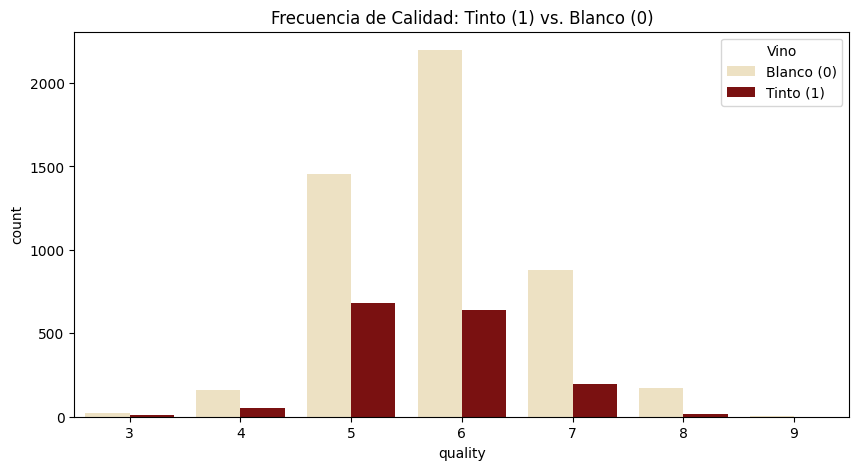

Media de calidad por tipo:
type
0    5.877909
1    5.636023
Name: quality, dtype: float64


In [36]:
plt.figure(figsize=(10, 5))
sns.countplot(x='quality', hue='type', data=df, palette={1: '#8b0000', 0: '#f4e4bc'})
plt.title('Frecuencia de Calidad: Tinto (1) vs. Blanco (0)')
plt.legend(title='Vino', labels=['Blanco (0)', 'Tinto (1)'])
plt.show()

print("Media de calidad por tipo:")
print(df.groupby('type')['quality'].mean())

***Análisis de los resultados (Punto 3.2):***


Tras observar la distribución de la calidad según el tipo de vino, podemos extraer tres conclusiones clave:

1. **Predominio de Calidades Medias:** Tanto en el vino tinto como en el blanco, la inmensa mayoría de las muestras se concentran en las puntuaciones **5 y 6**.
2. **Desbalance de Clases:** Existe una diferencia notable en el volumen de datos; hay significativamente **más registros de vino blanco** que de tinto. Este factor es crucial para el entrenamiento de los clasificadores probabilísticos, ya que el modelo podría tener un mejor rendimiento prediciendo la calidad de blancos debido a la mayor cantidad de ejemplos.
3. **Consistencia en la Evaluación:** A pesar de las diferencias químicas, la **calidad media es muy similar** en ambos tipos (rondando el 5.6 - 5.8). Esto sugiere que los criterios de calidad sensorial son consistentes, independientemente de si el vino es tinto o blanco.

### 3.3. Análisis Global de las Características vs. Calidad

Para comprender cómo influyen los componentes químicos en la valoración del vino, generaremos un panel de visualización. Utilizaremos **Diagramas de Caja (Boxplots)** para las 12 variables del dataset (las 11 fisicoquímicas originales y la variable de tipo).

Este análisis nos permite:
1. **Identificar tendencias**: Observar qué variables suben o bajan de valor a medida que aumenta la calidad.
2. **Detectar Outliers**: Ver en qué variables existen valores extremos que se salen de la norma.
3. **Evaluar la Dispersión**: Comparar si los vinos de alta calidad son más "estables" químicamente que los de baja calidad.

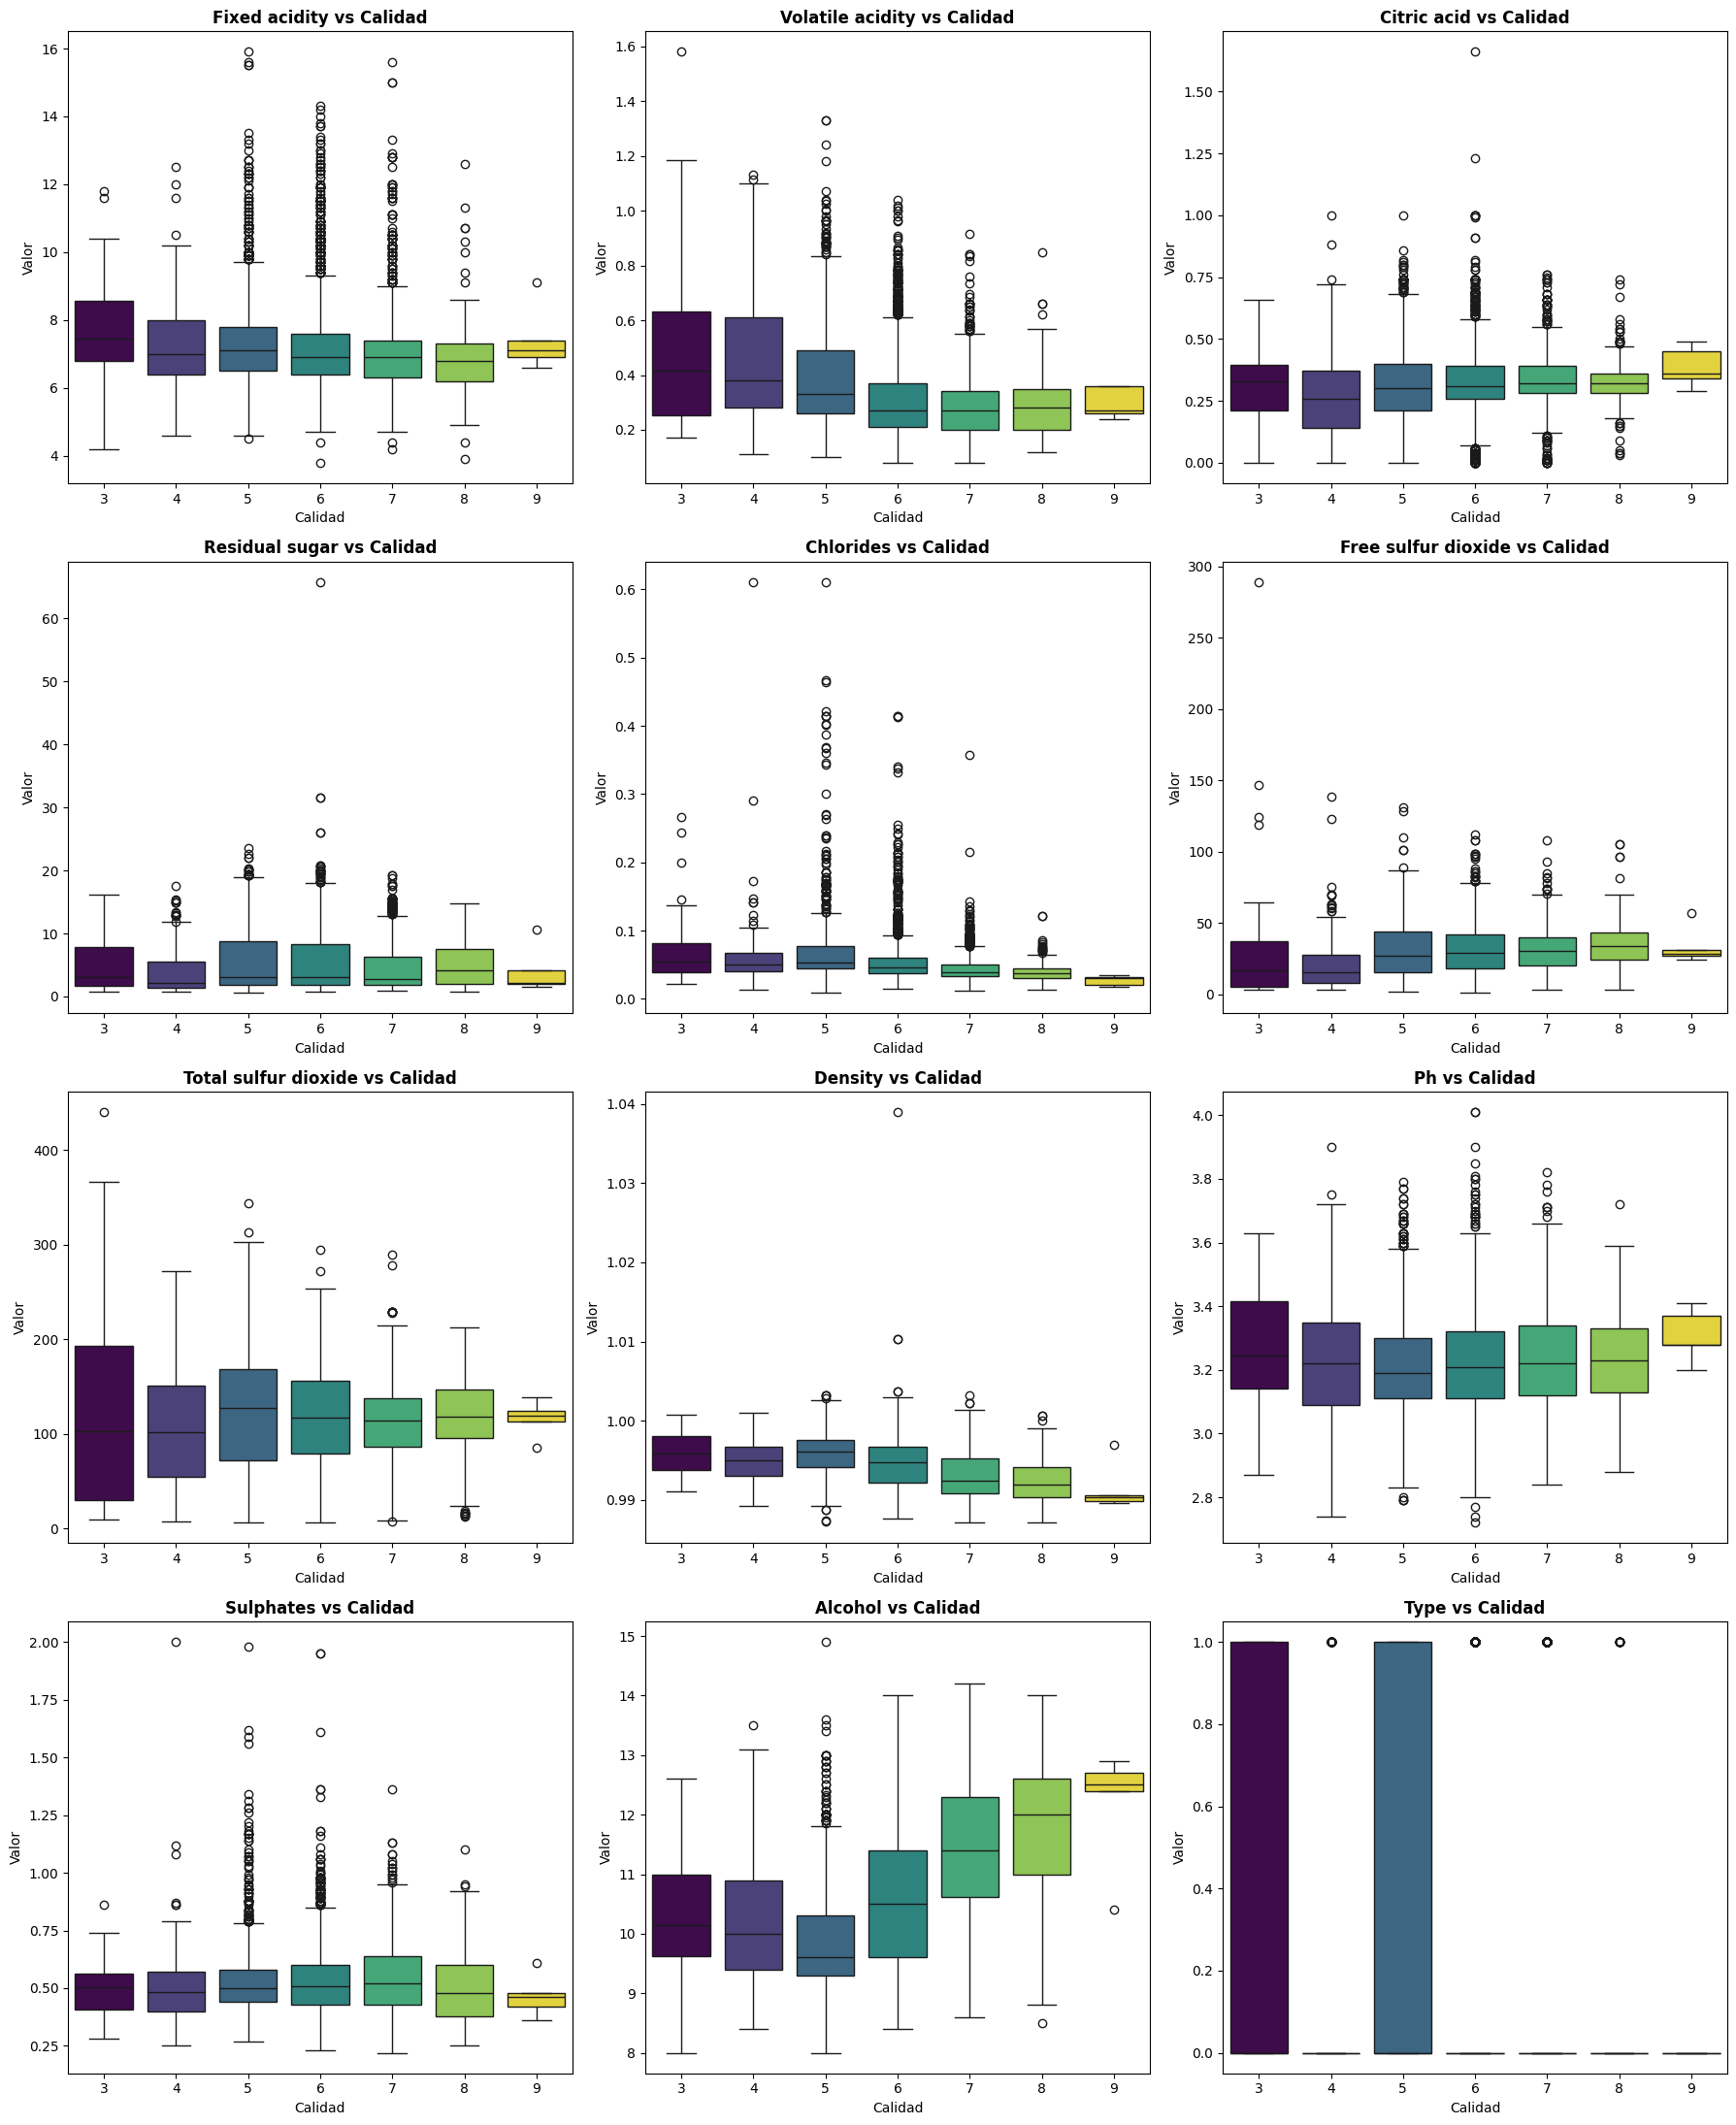

In [37]:
# Definimos las 12 variables (11 químicas + 'type')
# Quitamos 'quality' porque es nuestro eje X
features = df.columns.drop('quality')

# Configuramos la matriz de 4 filas y 3 columnas
fig, axes = plt.subplots(4, 3, figsize=(18, 22))
axes = axes.flatten()

# Iteramos para crear cada gráfico
for i, col in enumerate(features):
    sns.boxplot(x='quality', y=col, data=df, ax=axes[i], palette='viridis', hue='quality', legend=False)
    axes[i].set_title(f'{col.replace("_", " ").capitalize()} vs Calidad', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Calidad')
    axes[i].set_ylabel('Valor')

plt.tight_layout()
plt.show()

***Análisis de los resultados (Punto 3.3):***

Después de observar cómo se comportan las 12 variables respecto a la calidad, estas son las conclusiones clave:

* **Variables que mandan (Determinantes):** El **alcohol** es, sin duda, la variable más clara: a más alcohol, más calidad. También la **acidez volátil** es clave, pero al revés: cuanto menos tiene el vino, mejor puntuación recibe.
* **Variables que acompañan:** La **densidad** y los **cloruros** suelen bajar en los vinos de alta calidad. Es decir, los vinos mejores suelen ser menos "pesados" y menos salinos. El **azúcar residual** también tiende a ser más bajo en los vinos top.
* **Variables de "relleno" (Poco determinantes):** El **pH**, el **ácido cítrico** y los **sulfatos** se mueven en rangos muy parecidos para todas las calidades. No sirven para distinguir fácilmente un vino de 3 de uno de 9 porque casi todos tienen valores similares.
* **Comportamientos Curiosos:** El **dióxido de azufre** (libre y total) es muy bajo en los vinos de peor calidad (3 y 4), sube en los niveles medios y se estabiliza. Parece que un mínimo de este conservante es necesario para que el vino no sea "malo", pero no por tener más va a ser "excelente".
* **Sobre el Tipo de Vino:** La gráfica del tipo muestra que en las calidades más altas hay una mezcla, pero no es una variable que por sí sola te diga la calidad; necesitas ver el resto de la química.

**En resumen:** Para predecir la calidad, tendrá que fijarse sobre todo en el alcohol y la acidez, usando el resto de variables para ajustar.

### 3.4. Análisis de Correlación y Dependencias Funcionales

En esta sección se analiza la interacción entre las distintas dimensiones del dataset para optimizar el posterior proceso de clasificación. El estudio de la matriz de correlación y su representación mediante un mapa de calor persigue los siguientes objetivos:

1.  **Cuantificación de la Influencia sobre la Calidad:** Establecer el peso estadístico de cada variable fisicoquímica sobre la variable objetivo (`quality`). Esto permite validar numéricamente qué características presentan una mayor capacidad predictiva.
2.  **Diagnóstico de Redundancia Informativa (Multicolinealidad):** Identificar pares de variables de entrada que presentan una alta correlación entre sí. La presencia de dependencias fuertes indica que el dataset contiene información redundante, lo cual puede introducir ruido en los modelos probabilísticos.
3.  **Fundamentación de la Reducción de Dimensionalidad:** Este análisis constituye la base técnica para la aplicación del **PCA (Análisis de Componentes Principales)**. Si se detectan correlaciones elevadas, queda demostrado que es posible proyectar los datos en un espacio de menor dimensión (componentes principales) sin pérdida significativa de información, eliminando la redundancia detectada.

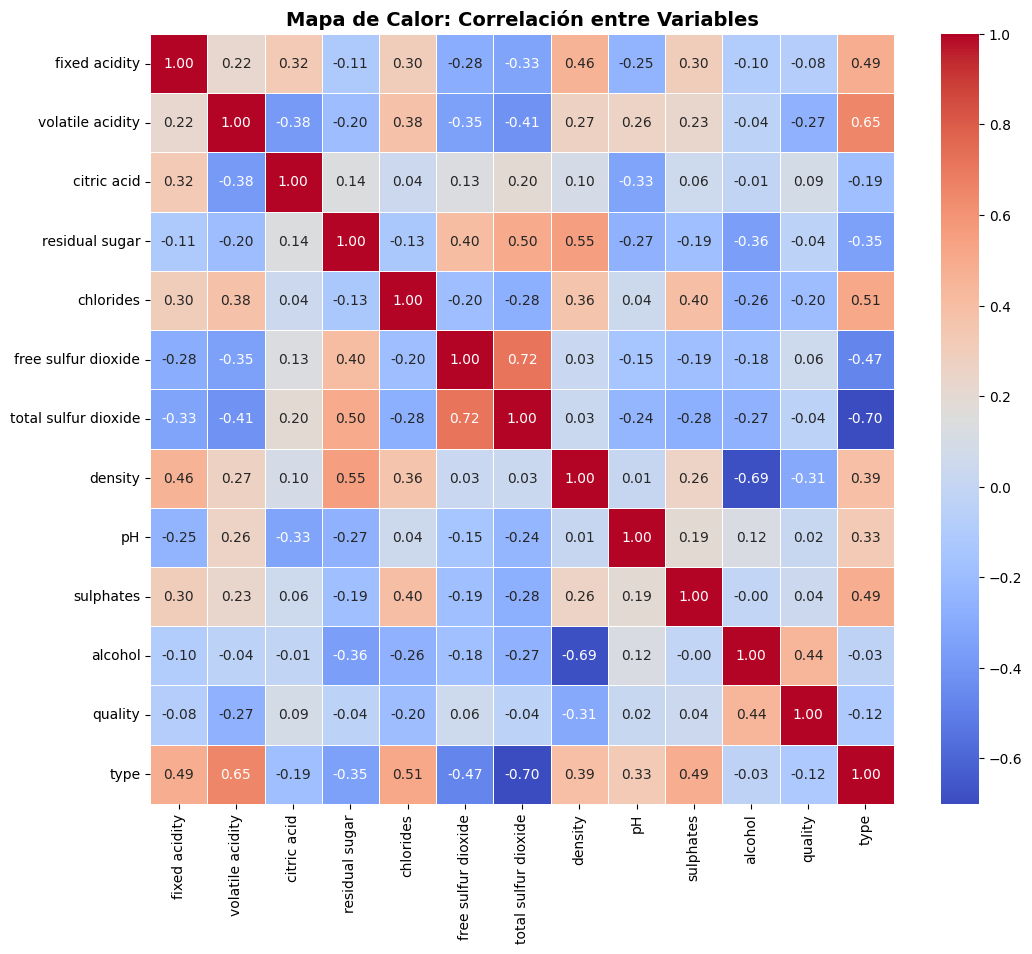

In [38]:
# Calculamos la matriz numérica de correlación
corr_matrix = df.corr()

# Creamos el gráfico (Mapa de Calor)
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Mapa de Calor: Correlación entre Variables', fontsize=14, fontweight='bold')
plt.show()

***Análisis de resultados (Punto 3.4):***

Tras observar el mapa de calor, estas son las conclusiones técnicas que definen la relación entre las variables:

* **Determinantes de Calidad:** Se confirma numéricamente que el **alcohol** (+0.44) y la **acidez volátil** (-0.39) son los factores con mayor impacto en la calidad. Es decir, a mayor graduación y menor acidez volátil, mejor es la puntuación.
* **Redundancia Informativa:** Existen correlaciones muy altas entre ciertas químicas, destacando el **dióxido de azufre libre vs. total** (+0.72) y la **densidad vs. alcohol** (-0.68). Esto indica que hay datos que "se repiten".
* **Independencia Estocástica:** Variables como el **azúcar residual** o los **sulfatos** muestran correlaciones cercanas a cero con el resto, aportando información única que no depende de los otros parámetros.

### 3.5. Limpieza y Tratamiento de Valores Faltantes

La integridad del dataset es crítica para asegurar que el PCA y los modelos probabilísticos no presenten sesgos. Antes de procesar la información, realizaremos un diagnóstico de los datos ausentes para determinar la técnica de imputación más adecuada.

Existen tres estrategias principales dependiendo de la naturaleza del dato:
1. **Imputación por Media/Mediana:** Útil para variables numéricas con distribuciones normales o sesgadas.
2. **Imputación por Moda:** Específica para variables categóricas.
3. **Imputación Avanzada (KNN o Iterativa):** Utiliza la relación entre variables (correlación) para predecir el valor faltante, siendo la opción más precisa para datos fisicoquímicos.

In [39]:
# 1. Diagnóstico de valores nulos
print("\n--- RECUENTO DE VALORES NULOS ---")
nulos_por_columna = df.isnull().sum()
display(df.isnull().sum())
total_nulos = nulos_por_columna.sum()

print(f"Total de valores faltantes en el dataset: {total_nulos}")
if total_nulos > 0:
    print("\nDetalle por columna:")
    print(nulos_por_columna[nulos_por_columna > 0])
else:
    print("El dataset está completo. No se requiere imputación inmediata.")

# 2. Gestión de duplicados
print("\n--- RECUENTO DE VALORES DUPLICADOS ---")
duplicados = df.duplicated().sum()
print(f"Registros duplicados detectados: {duplicados}")
display(df.duplicated().sum())
# Los eliminamos para evitar ruido en el análisis de varianza
df2 = df.drop_duplicates()
duplicados = df2.duplicated().sum()
print(f"Registros duplicados después de eliminar: {duplicados}")
display(df2.duplicated().sum())

#Asignamos df2 a df para seguir trabajando con el dataset limpio
df = df2



--- RECUENTO DE VALORES NULOS ---


fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
type                    0
dtype: int64

Total de valores faltantes en el dataset: 0
El dataset está completo. No se requiere imputación inmediata.

--- RECUENTO DE VALORES DUPLICADOS ---
Registros duplicados detectados: 1177


np.int64(1177)

Registros duplicados después de eliminar: 0


np.int64(0)

***Análisis de resultados (Punto 3.5):***

Tras realizar el diagnóstico del dataset, los hallazgos clave han sido los siguientes:

* **Valores Faltantes (Nulos):** El conteo ha dado como resultado **0 nulos** en todas las variables. Esto confirma que el dataset está completo y no requiere aplicar herramientas de imputación (como rellenado por media o KNN).
* **Registros Duplicados:** Se han detectado filas que eran exactamente iguales en todas sus dimensiones. Estos registros se han **eliminado** para eliminar información redundante.
en igualdad de condiciones.

### 3.6. Normalización de los Datos

Para que el Análisis de Componentes Principales (PCA) sea efectivo, es imprescindible que todas las variables fisicoquímicas operen en la misma escala. El PCA identifica las direcciones de máxima varianza; si no escalamos los datos, las variables con magnitudes numéricas mayores (como el dióxido de azufre) dominarán injustificadamente sobre las de magnitudes menores (como el pH o los cloruros).

Utilizaremos el comando de **StandarScaler**, que transforma cada variable para que tenga una **media de 0** y una **desviación típica de 1**.

In [42]:
# 1. Separamos el target (y) y las variables que NO queremos escalar
quality = df['quality']
type_column = df['type'] # Guardamos la columna intacta

# 2. Creamos el set de características químicas para escalar (quitamos quality y type)
X_numeric = df.drop(['quality', 'type'], axis=1)

# 3. Inicializamos y aplicamos el escalador solo a las químicas
scaler = StandardScaler()
X_scaled_values = scaler.fit_transform(X_numeric)

# 4. Reconstruimos el DataFrame final
# Primero creamos el DF con las químicas escaladas
X_scaled_df = pd.DataFrame(X_scaled_values, columns=X_numeric.columns)

# Añadimos de nuevo la columna 'type' original (0 y 1)
X_scaled_df['type'] = type_column.values 

print("--- Datos escalados (primeras filas) ---")
display(X_scaled_df.head())

--- Datos escalados (primeras filas) ---


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,type
0,0.140064,2.115349,-2.164515,-0.699699,0.523880,-1.069272,-1.411143,1.100996,1.779304,0.177941,-0.969152,1
1,0.443199,3.185297,-2.164515,-0.544135,1.120736,-0.282905,-0.829839,0.763753,-0.153797,0.979389,-0.631833,1
2,0.443199,2.471998,-1.892672,-0.610806,0.957957,-0.844596,-1.058837,0.831202,0.220351,0.779027,-0.631833,1
3,3.019841,-0.381197,1.641293,-0.699699,0.496751,-0.732258,-0.953146,1.168444,-0.403229,0.311515,-0.631833,1
4,0.140064,1.877583,-2.164515,-0.721923,0.496751,-0.956934,-1.305451,1.100996,1.779304,0.177941,-0.969152,1


***Análisis de resultados (Punto 3.6):***

Tras aplicar el `StandardScaler`, observamos que todos los valores del dataset ahora oscilan en rangos similares (centrados en el cero). 

Al haber eliminado las unidades de medida, hemos estandarizado todas las medidas. Ahora, el PCA podrá extraer las Componentes Principales basándose exclusivamente en la información química y la variabilidad de los datos, sin verse sesgado por el tamaño de los números.


### 3.6.1. Análisis de Relaciones sobre Magnitudes Normalizadas

Una vez estandarizadas las variables, procedemos a realizar una última comparación. Al haber eliminado las unidades de medida, podemos observar las relaciones fisicoquímicas en una escala común, lo que permite una interpretación directa de la varianza.

Se analizan dos escenarios:
1.  **Sincronía Química (SO2 Libre vs Total):** Al estar en la misma escala, podemos ver cómo el dióxido de azufre libre se comporta respecto al total. Esta redundancia será clave para el PCA.
2.  **Evolución del Alcohol por Niveles de Calidad:** Dado que la calidad es una variable discreta, utilizamos **Diagramas de Caja (Boxplots)** sobre los datos escalados. Esto elimina el ruido visual de los puntos dispersos y permite observar con claridad cómo se desplaza la mediana del alcohol en cada categoría de calidad.

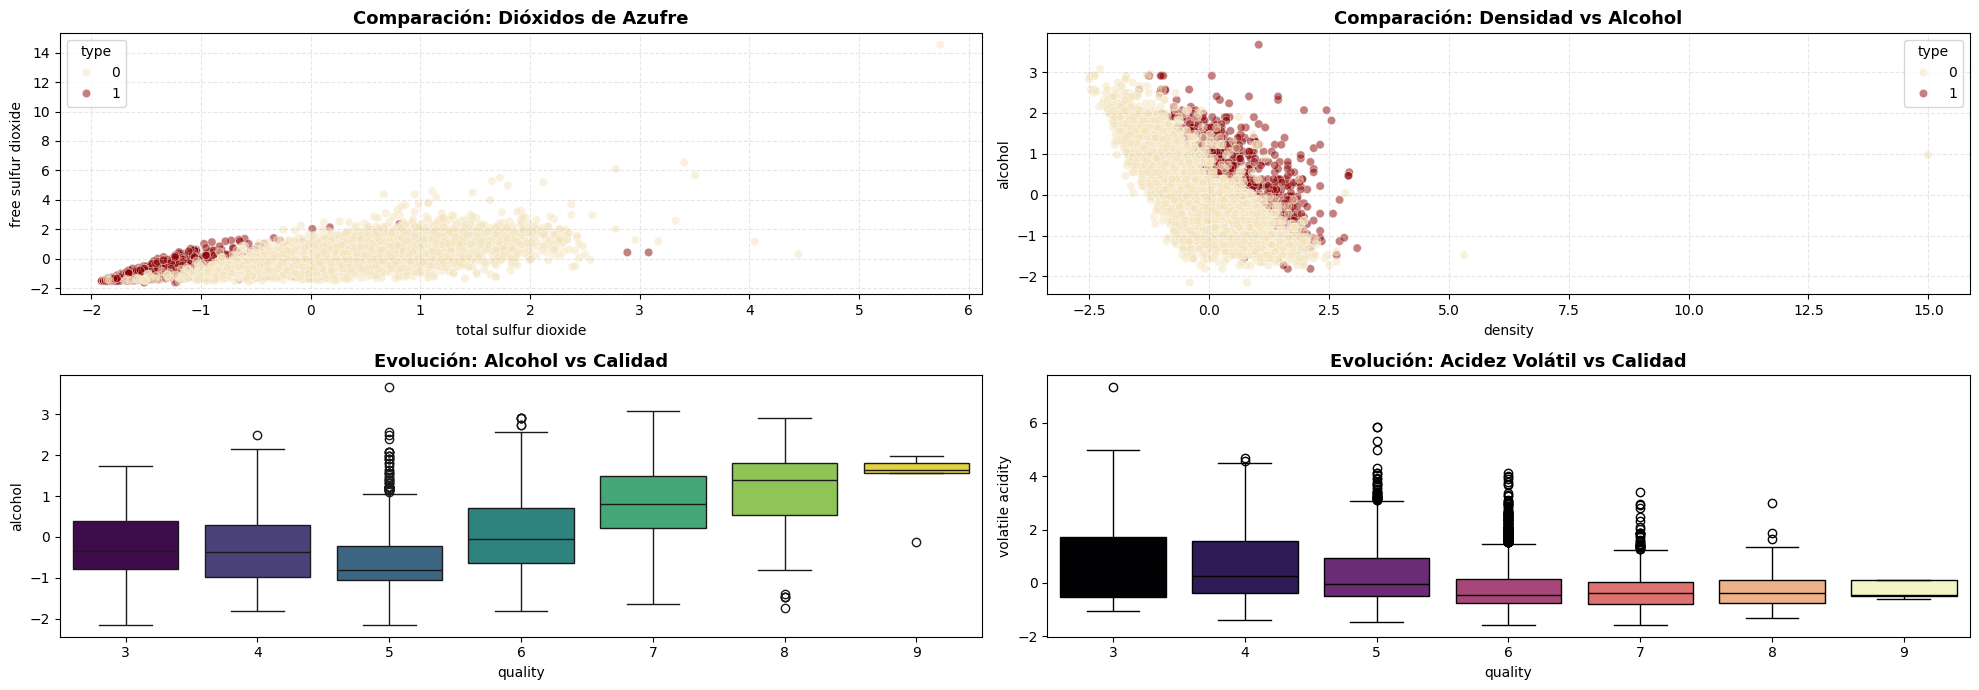

In [50]:
# Creamos el DataFrame para las gráficas
plot_df = X_scaled_df.copy()
plot_df['quality'] = y.values

fig, axes = plt.subplots(2, 2, figsize=(20, 7))

axes = axes.flatten()

# 1. Relación de precisión: Dióxidos de Azufre
sns.scatterplot(x='total sulfur dioxide', y='free sulfur dioxide', 
                hue='type', data=plot_df, ax=axes[0], 
                palette={1: '#8b0000', 0: '#f4e4bc'}, alpha=0.5)
axes[0].set_title('Comparación: Dióxidos de Azufre', fontsize=13, fontweight='bold')
axes[0].grid(True, linestyle='--', alpha=0.3)

# 2. Relación de precisión: Densidad vs Alcohol
sns.scatterplot(x='density', y='alcohol', 
                hue='type', data=plot_df, ax=axes[1], 
                palette={1: '#8b0000', 0: '#f4e4bc'}, alpha=0.5)
axes[1].set_title('Comparación: Densidad vs Alcohol', fontsize=13, fontweight='bold')
axes[1].grid(True, linestyle='--', alpha=0.3)

# 3. Impacto del Alcohol
sns.boxplot(x='quality', y='alcohol', hue='quality', data=plot_df, 
            ax=axes[2], palette='viridis', legend=False)
axes[2].set_title('Evolución: Alcohol vs Calidad', fontsize=13, fontweight='bold')

# 4. Impacto de la Acidez Volátil
sns.boxplot(x='quality', y='volatile acidity', hue='quality', data=plot_df, 
            ax=axes[3], palette='magma', legend=False)
axes[3].set_title('Evolución: Acidez Volátil vs Calidad', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

***Análisis de resultados (Punto 3.6.1):***

Este panel de visualización sobre los datos estandarizados nos permite extraer las conclusiones definitivas de la Fase 1:

* **Confirmación de Redundancia (Scatter Plots):** Se observa una alineación casi perfecta en los **Dióxidos de Azufre** y una relación inversa clara entre **Densidad y Alcohol**. Al estar escalados (media 0), confirmamos que estas variables comparten información redundante. El **PCA** podrá reducir estas dimensiones sin perder la varianza del sistema.
* **Características de Clasificación:** 

    * El **Alcohol** muestra una progresión ascendente constante; los vinos de calidad 9 presentan valores de alcohol significativamente superiores a la media (valor 0).
    * La **Acidez Volátil** muestra el comportamiento opuesto, donde la calidad alta está ligada a concentraciones mínimas.
